In [1]:
import os
from datetime import datetime
import json
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from conv_autoencoder import ConvAutoencoder
from resnet_autoencoder import ResnetAutoencoder

In [2]:
DATA_DIR = 'D:/HCMUT_Workspace/HK251/Digital-Image-Processing-and-Computer-Vision/assignment/photo2painting/monet_style_dataset'
MODEL_DIR = 'D:/HCMUT_Workspace/HK251/Digital-Image-Processing-and-Computer-Vision/assignment/photo2painting/models'

In [3]:
class PhotoPaintingDataset(Dataset):
    """
    A dataset for paired image-to-image tasks.
    Expects:
        root/photos/xxx.jpg
        root/sketches/xxx.jpg
    with matching filenames in both folders.
    """
    def __init__(self, photos_dir, paintings_dir, indices=None):
        self.photos_dir = photos_dir
        self.paintings_dir = paintings_dir

        # Ensure paired correctly (same length & matching names)
        assert len(os.listdir(photos_dir)) == len(os.listdir(paintings_dir)), \
            "Mismatch in number of files between photos and sketches."

        self.filenames = os.listdir(photos_dir)
        # If indices (train/test) are passed, keep only those
        if indices is not None:
            self.filenames = [self.filenames[i] for i in indices]

        # Match file names in both folders
        self.filenames = sorted(self.filenames)

        self.transformer = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        photo_path = os.path.join(self.photos_dir, self.filenames[idx])
        painting_path = os.path.join(self.paintings_dir, self.filenames[idx])

        photo = Image.open(photo_path).convert("RGB")
        painting = Image.open(painting_path).convert("RGB")  # paintingscale target

        photo = self.transformer(photo)
        painting = self.transformer(painting)

        return photo, painting

In [4]:
photos_dir = os.path.join(DATA_DIR, 'original')
paintings_dir = os.path.join(DATA_DIR, 'stylized')

all_files = sorted(os.listdir(photos_dir))
train_idx, test_idx = train_test_split(range(len(all_files)), test_size=0.2, random_state=42)

train_dataset = PhotoPaintingDataset(photos_dir, paintings_dir, indices=train_idx)
test_dataset = PhotoPaintingDataset(photos_dir, paintings_dir, indices=test_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [5]:
def load_model(model_class, ckpt_path, map_location="cpu"):
    """Rebuild model from config and load weights."""
    ckpt = torch.load(ckpt_path, map_location=map_location)
    model = model_class(3, 3, ckpt.get("config", {})['hidden_channels'])
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return model, ckpt

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
model = load_model(ResnetAutoencoder, os.path.join(MODEL_DIR, 'resnet_autoencoder_L1Loss.pt'))[0]
model = model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0581241].


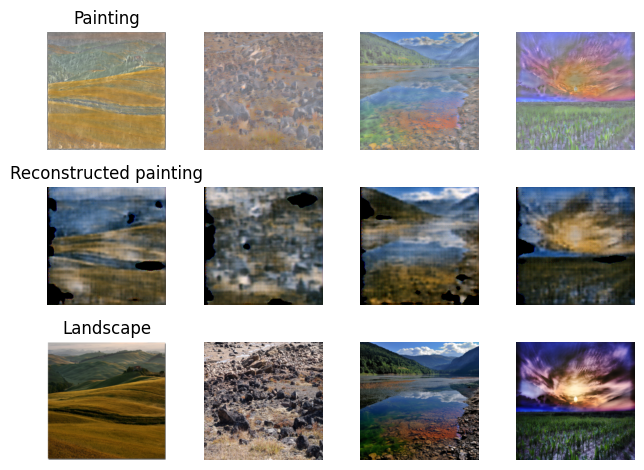

In [10]:
def show_examples(model, data_loader, idx, device, num_examples=4):
    model.eval()
    with torch.no_grad():
        it = iter(data_loader)
        photo, painting = next(it)
        for i in range(idx):
          photo, painting = next(it)

        painting, photo = painting.to(device), photo.to(device)
        output = model(painting)

        painting = painting.cpu().numpy()
        photo = photo.cpu().numpy()
        output = output.cpu().numpy()

        fig, axes = plt.subplots(3, num_examples)
        for i in range(num_examples):
            # Display paintingscale input
            axes[0, i].imshow(painting[i].transpose(1, 2, 0))
            axes[0, i].axis('off')
            # Display predicted photo output
            axes[1, i].imshow(output[i].transpose(1, 2, 0))
            axes[1, i].axis('off')
            # Display ground truth
            axes[2, i].imshow(photo[i].transpose(1, 2, 0))
            axes[2, i].axis('off')

        axes[0, 0].set_title("Painting")
        axes[1, 0].set_title("Reconstructed painting")
        axes[2, 0].set_title("Landscape")
        plt.tight_layout()
        plt.show()
        
show_examples(model, test_loader, 6, device)

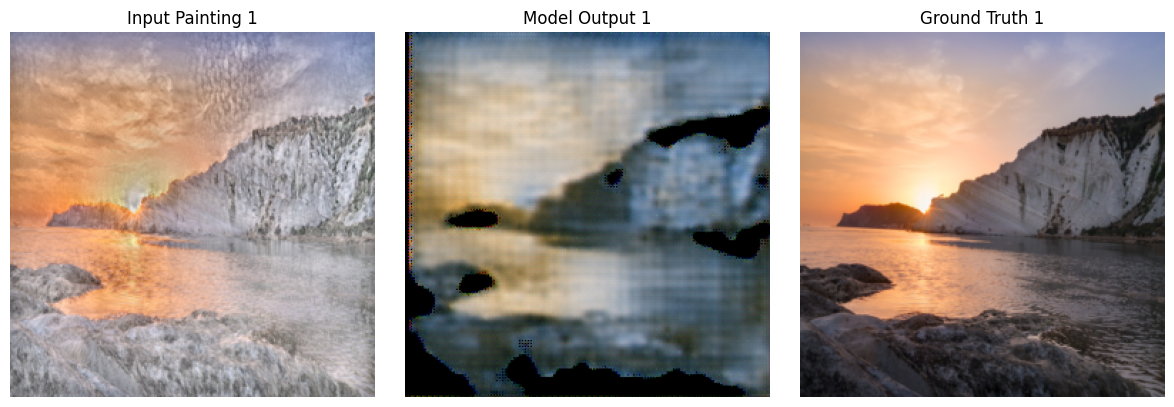

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1863723].


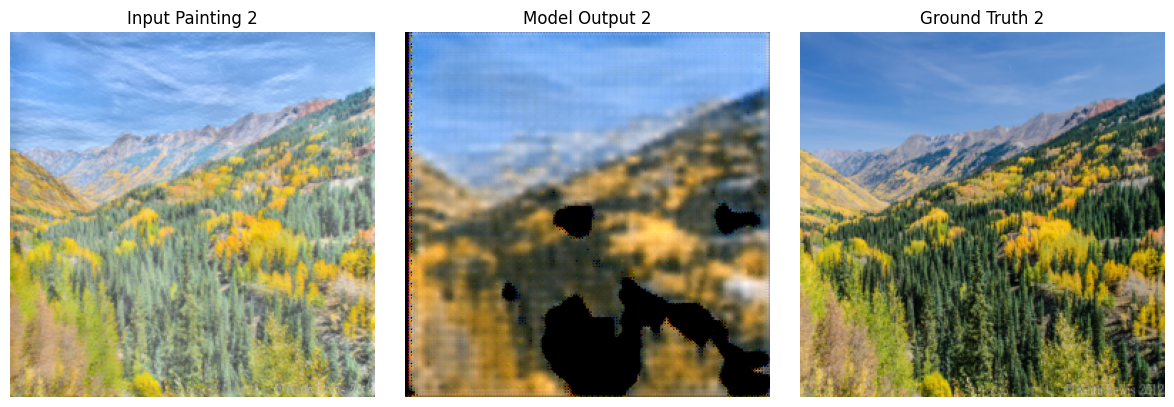

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0851364].


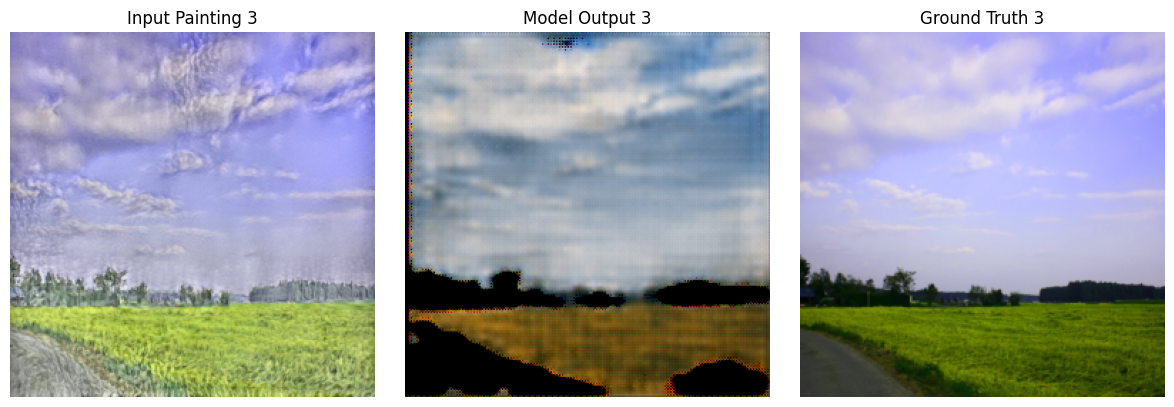

In [12]:
def show_individual_examples(model, data_loader, start_idx, device, num_examples=3):
    model.eval()
    with torch.no_grad():
        it = iter(data_loader)
        photo, painting = next(it)
        for i in range(start_idx):
            photo, painting = next(it)

        painting, photo = painting.to(device), photo.to(device)
        output = model(painting)

        painting = painting.cpu().numpy()
        photo = photo.cpu().numpy()
        output = output.cpu().numpy()

        # Show each example separately
        for i in range(num_examples):
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            
            # Input painting
            axes[0].imshow(painting[i].transpose(1, 2, 0))
            axes[0].set_title(f"Input Painting {i+1}")
            axes[0].axis('off')
            
            # Model output
            axes[1].imshow(output[i].transpose(1, 2, 0))
            axes[1].set_title(f"Model Output {i+1}")
            axes[1].axis('off')
            
            # Ground truth
            axes[2].imshow(photo[i].transpose(1, 2, 0))
            axes[2].set_title(f"Ground Truth {i+1}")
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()

# Usage
show_individual_examples(model, test_loader, 8, device)